**1. Introduction**

In [1]:
from pandas.core.indexes import category
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Apriori
from mlxtend.frequent_patterns import apriori, association_rules

# Set overall theme
sns.set_theme(style="whitegrid")

# Set a consistent color palette
sns.set_palette("Blues_d")
colors = sns.color_palette("Blues", 7)

# Optional: improve figure aesthetics
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category = DeprecationWarning)

In [2]:
# Importing datasets.

df1 = pd.read_csv('aisles.csv')
#print(df1.head())
df2 = pd.read_csv('order_products__train.csv')
#print(df2.head())
df3 = pd.read_csv('orders.csv')
#print(df3.head())
df4 = pd.read_csv('products.csv')
#print(df4.head())
df5 = pd.read_csv('departments.csv')
#print(df5.head())

# Merging datasets on the unique column id's.

df11 = pd.merge(df1, df4, how = 'inner', on = 'aisle_id')
df22 = pd.merge(df11, df5, how = 'inner', on = 'department_id')
df33 = pd.merge(df22, df2, how = 'inner', on = 'product_id')
df44 = pd.merge(df33, df3, how = 'inner', on = 'order_id')

# Dropping redundant features.

df = df44.drop(['aisle_id', 'product_id', 'department_id', 'eval_set', 'order_number'], axis = 1)
df.head()

,aisle,product_name,department,order_id,add_to_cart_order,reordered,user_id,order_dow,order_hour_of_day,days_since_prior_order
0,prepared soups salads,Italian Pasta Salad,deli,36461,6,1,50978,6,13,20.0
1,prepared soups salads,Italian Pasta Salad,deli,989729,6,1,119977,1,16,27.0
2,prepared soups salads,Italian Pasta Salad,deli,1143158,5,1,154727,5,14,7.0
3,prepared soups salads,Italian Pasta Salad,deli,1307275,11,0,29486,0,21,30.0
4,prepared soups salads,Italian Pasta Salad,deli,1504504,27,0,839,1,13,30.0


In [3]:
df.shape

(1384617, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   aisle                   1384617 non-null  object 
 1   product_name            1384617 non-null  object 
 2   department              1384617 non-null  object 
 3   order_id                1384617 non-null  int64  
 4   add_to_cart_order       1384617 non-null  int64  
 5   reordered               1384617 non-null  int64  
 6   user_id                 1384617 non-null  int64  
 7   order_dow               1384617 non-null  int64  
 8   order_hour_of_day       1384617 non-null  int64  
 9   days_since_prior_order  1384617 non-null  float64
dtypes: float64(1), int64(6), object(3)
memory usage: 105.6+ MB


In [5]:
df.describe()

,order_id,add_to_cart_order,reordered,user_id,order_dow,order_hour_of_day,days_since_prior_order
count,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06
mean,1.706298e+06,8.758044e+00,5.985944e-01,1.031128e+05,2.701392e+00,1.357759e+01,1.706613e+01
std,9.897326e+05,7.423936e+00,4.901829e-01,5.948715e+04,2.167646e+00,4.238458e+00,1.042642e+01
min,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.433700e+05,3.000000e+00,0.000000e+00,5.173200e+04,1.000000e+00,1.000000e+01,7.000000e+00
50%,1.701880e+06,7.000000e+00,1.000000e+00,1.029330e+05,3.000000e+00,1.400000e+01,1.500000e+01
75%,2.568023e+06,1.200000e+01,1.000000e+00,1.549590e+05,5.000000e+00,1.700000e+01,3.000000e+01
max,3.421070e+06,8.000000e+01,1.000000e+00,2.062090e+05,6.000000e+00,2.300000e+01,3.000000e+01


In [6]:
df.nunique().sort_values(ascending = False)

,0
user_id,131209
order_id,131209
product_name,39123
aisle,134
add_to_cart_order,80
days_since_prior_order,31
order_hour_of_day,24
department,21
order_dow,7
reordered,2


**2. Dataset Understanding**

The dataset contains customer grocery order transactions from Instacart, including product details, customer ordering behavior, and reorder information. It can be used to analyze purchasing patterns, customer habits, product associations, and retail business insights.
```
aisle:                   Category grouping that describes the type of products.
product_name:            Name of the product.
department:              Higher-level category the product belongs to.
order_id:                Unique identifier for each order (represents a basket).
add_to_cart_order:       Sequence in which products were added to the cart within an order.
reordered:               Indicates whether the product has been previously purchased by the same user (1 = yes, 0 = no).
user_id:                 Unique identifier for each customer.
order_dow:               Day of the week the order was placed (0 = Sunday).
order_hour_of_day:       Hour of the day the order was placed (0 = 12 AM, 23 = 11 PM).
days_since_prior_order:  Number of days since the user’s previous order.
```

**3. Exploratory Data Analysis**

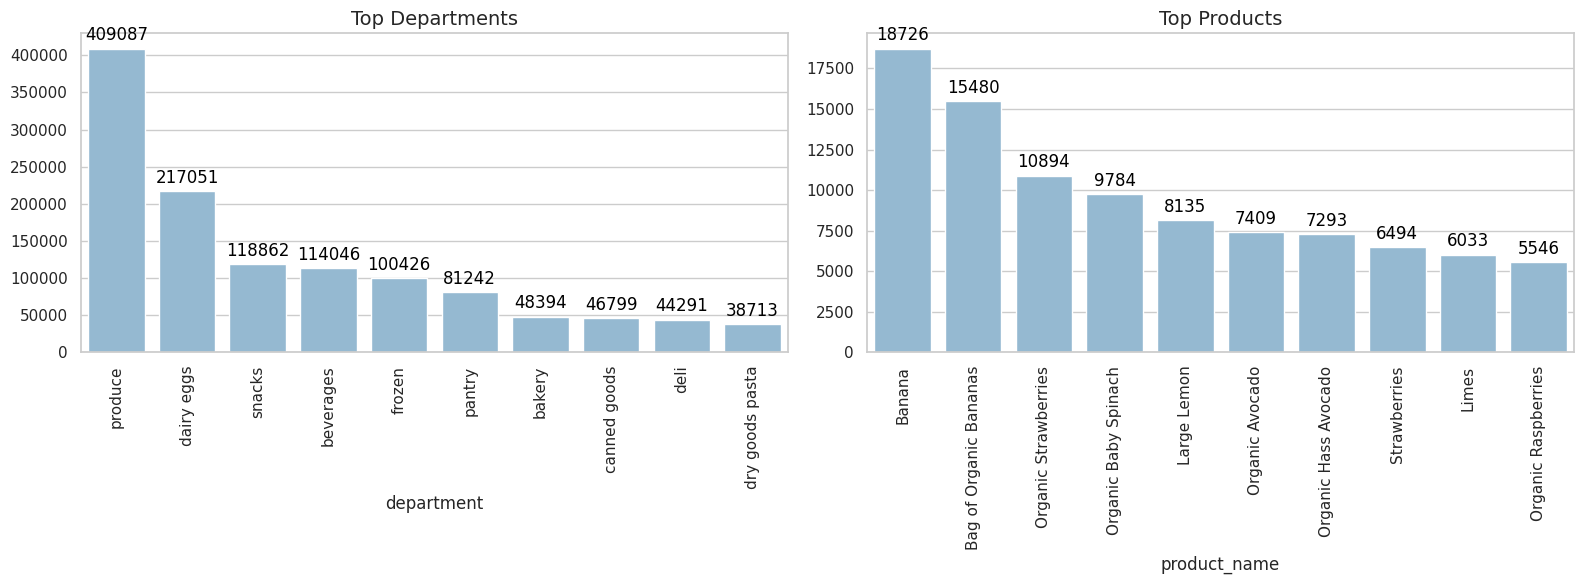

In [7]:
top_departments = df['department'].value_counts().head(10)
top_products = df['product_name'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Departments
sns.barplot(x=top_departments.index, y=top_departments.values, ax=axes[0])
axes[0].set_title("Top Departments")
axes[0].tick_params(axis='x', rotation=90)

# Add labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', padding=3, color='black')

# Products
sns.barplot(x=top_products.index, y=top_products.values, ax=axes[1])
axes[1].set_title("Top Products")
axes[1].tick_params(axis='x', rotation=90)

# Add labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3, color='black')

plt.tight_layout()
plt.show()



*   The top 10 departments are all food, with fresh produce dominating the list.
*   The top 10 products are all from the produce itself indicating high demand.




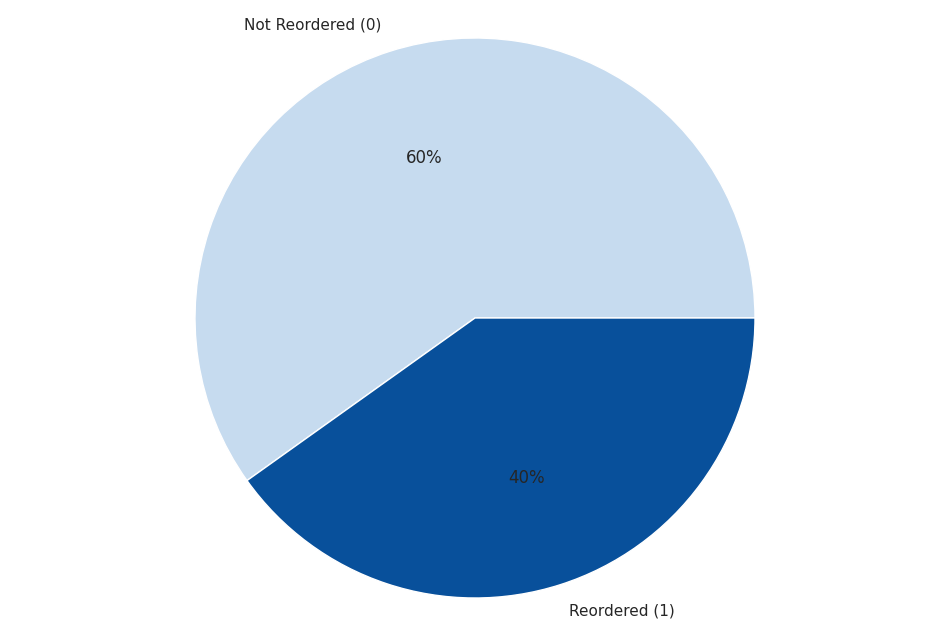

Approximately 40% of the purchased products were reordered, indicating a strong level of repeat purchasing behavior among customers.
At the same time, nearly 60% of products were non-reordered, suggesting that customers also explore new or infrequently purchased items regularly.


In [8]:
reordered_counts = df['reordered'].value_counts()

pie_colors = [colors[1], colors[6]]
labels = ["Not Reordered (0)", "Reordered (1)"]

plt.pie(reordered_counts.values, labels=labels, autopct='%.0f%%', colors=pie_colors)
plt.axis('equal')
plt.show()

print("Approximately 40% of the purchased products were reordered, indicating a strong level of repeat purchasing behavior among customers.")
print("At the same time, nearly 60% of products were non-reordered, suggesting that customers also explore new or infrequently purchased items regularly.")

In [9]:
day_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}

day_counts = df['order_dow'].value_counts().sort_index()
day_counts.index = day_counts.index.map(day_map)

Customer ordering activity appears to peak during weekends, particularly on Sundays, suggesting that many customers prefer completing their
weekly grocery shopping during this period.
Order volume remains consistently high between 10 AM and 5 PM, with over 100,000 orders placed during each hour in this time range. After 5 PM,
order activity gradually declines throughout the evening and reaches its lowest levels between midnight and 7 AM, where hourly orders fall below 20,000.


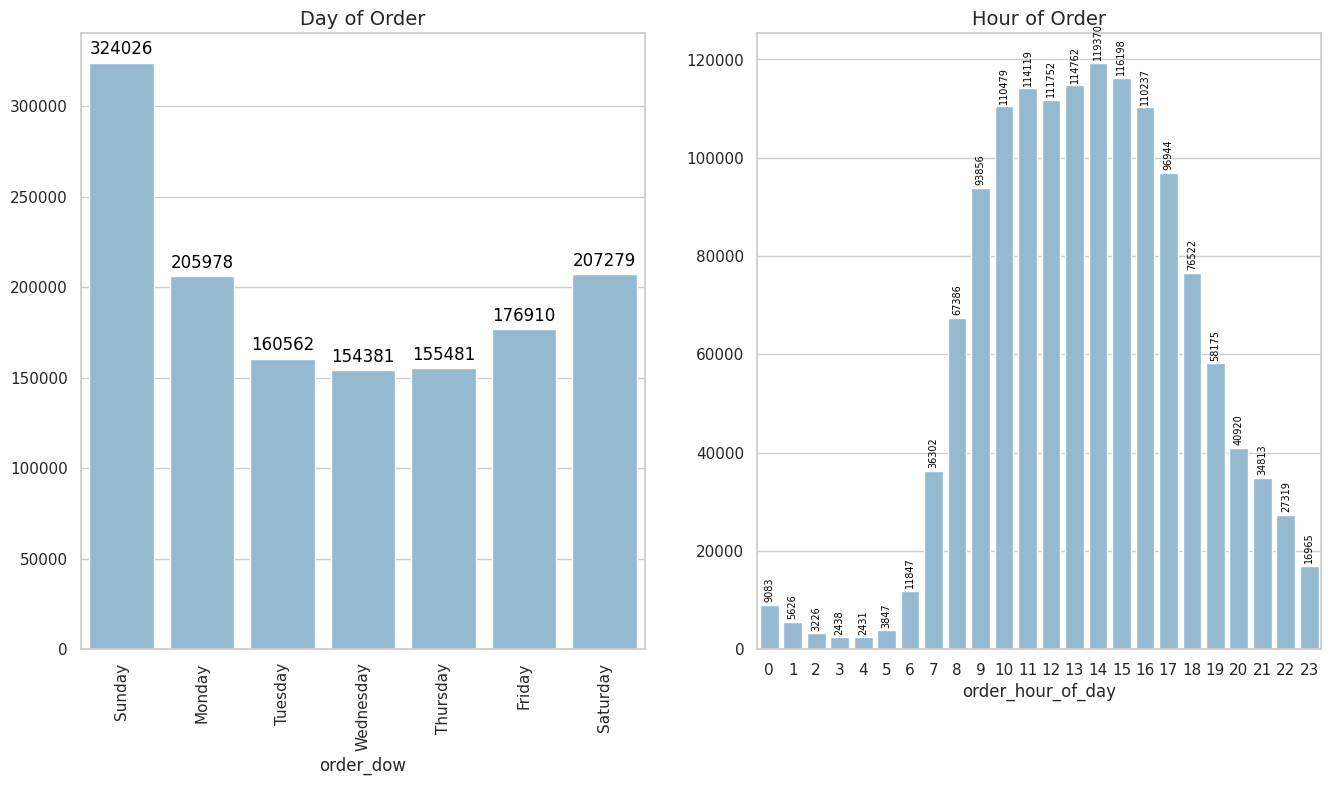

In [10]:
hours = df['order_hour_of_day'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))


# days
sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[0])
axes[0].set_title("Day of Order")
axes[0].tick_params(axis='x', rotation=90)
# Add labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', padding=3, color='black')


# hours
sns.barplot(x=hours.index, y=hours.values, ax=axes[1])
axes[1].set_title("Hour of Order")
axes[1].tick_params(axis='x')
# Add labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f',fontsize=7, padding=2, rotation=90, color='black')

print("Customer ordering activity appears to peak during weekends, particularly on Sundays, suggesting that many customers prefer completing their")
print("weekly grocery shopping during this period.")
print("Order volume remains consistently high between 10 AM and 5 PM, with over 100,000 orders placed during each hour in this time range. After 5 PM,")
print("order activity gradually declines throughout the evening and reaches its lowest levels between midnight and 7 AM, where hourly orders fall below 20,000.")

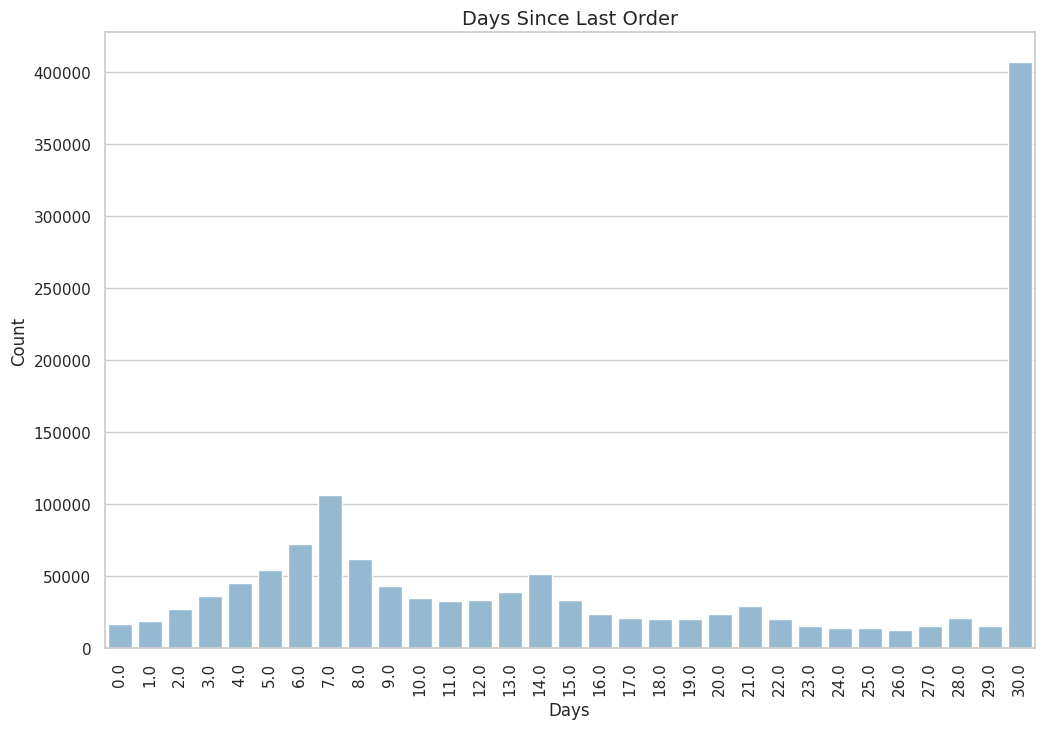

A significant number of customers placed their next order after 30 days since their previous purchase, indicating the presence of monthly or infrequent shopping behavior.
Additionally, a noticeable spike was observed at 7 days, suggesting that many customers follow a weekly grocery purchasing cycle.


In [11]:
prev_order = df['days_since_prior_order'].value_counts()

ax = sns.barplot(x=prev_order.index, y=prev_order.values)
plt.title("Days Since Last Order")
plt.xlabel("Days")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

print("A significant number of customers placed their next order after 30 days since their previous purchase, indicating the presence of monthly or infrequent shopping behavior.")
print("Additionally, a noticeable spike was observed at 7 days, suggesting that many customers follow a weekly grocery purchasing cycle.")

**4. Insights from EDA**

1. Fresh produce products dominated the top-selling items, with fruits and vegetables contributing significantly to customer purchases.

2. The produce department accounted for a large share of frequently purchased products, indicating strong customer demand for grocery and fresh food items.

3. Around 40% of purchased items were reordered, showing consistent repeat purchasing behavior and customer loyalty toward frequently used grocery products.

4. Customer ordering activity peaked during weekends, especially Sundays, suggesting that many customers prefer placing grocery orders during weekly restocking periods.

5. Order volume remained highest between 10 AM and 5 PM, while overnight hours showed significantly lower activity.

6. A noticeable spike in orders was observed at 7 days since prior order, indicating weekly purchasing behavior among customers.

7. A large number of customers also reordered after 30 days, suggesting the presence of monthly or infrequent shopping patterns.

**5. Market Basket Analysis**

In [12]:
df_sample = df.copy()

In [13]:
df_sample['product_name'].value_counts().head(20).sum()

np.int64(138886)

In [14]:
df_sample = df_sample[df_sample['product_name'].isin(df_sample['product_name'].value_counts().head(20).index)]
df_sample

,aisle,product_name,department,order_id,add_to_cart_order,reordered,user_id,order_dow,order_hour_of_day,days_since_prior_order
177108,fresh fruits,Bag of Organic Bananas,produce,1,6,0,112108,4,10,9.0
177109,fresh fruits,Bag of Organic Bananas,produce,98,4,1,56463,3,8,14.0
177110,fresh fruits,Bag of Organic Bananas,produce,170,3,1,182389,0,13,14.0
177111,fresh fruits,Bag of Organic Bananas,produce,1077,1,1,173934,6,9,10.0
177112,fresh fruits,Bag of Organic Bananas,produce,1325,2,1,171686,3,17,4.0
...,...,...,...,...,...,...,...,...,...,...
1329705,packaged vegetables fruits,Organic Grape Tomatoes,produce,3417658,2,1,30587,0,15,15.0
1329706,packaged vegetables fruits,Organic Grape Tomatoes,produce,3419083,4,1,13944,3,21,5.0
1329707,packaged vegetables fruits,Organic Grape Tomatoes,produce,3419408,23,1,31527,3,20,20.0
1329708,packaged vegetables fruits,Organic Grape Tomatoes,produce,3420257,32,1,92532,6,17,7.0


In [15]:
df_sample.nunique()

,0
aisle,4
product_name,20
department,2
order_id,69116
add_to_cart_order,67
reordered,2
user_id,69116
order_dow,7
order_hour_of_day,24
days_since_prior_order,31


*Original Dataset:*
1.38M rows, 131k orders and 39k products

*Filtered Dataset:*
138k rows, 69l orders and 20 unique products.

Retained many baskets while drastically reducing dimensionality.

In [16]:
# Pivot Table.
# Each row is a unique order and the columns should be product_names.

df_pivot = df_sample.assign(value=1).pivot_table(
    index='order_id', columns='product_name', values='value', aggfunc='max', fill_value=0
).reset_index()

df_pivot.shape

(69116, 21)

In [17]:
df_pivot.columns

Index(['order_id', 'Asparagus', 'Bag of Organic Bananas', 'Banana',
       'Large Lemon', 'Limes', 'Organic Avocado', 'Organic Baby Spinach',
       'Organic Blueberries', 'Organic Cucumber', 'Organic Garlic',
       'Organic Grape Tomatoes', 'Organic Hass Avocado', 'Organic Raspberries',
       'Organic Red Onion', 'Organic Strawberries', 'Organic Whole Milk',
       'Organic Yellow Onion', 'Organic Zucchini', 'Seedless Red Grapes',
       'Strawberries'],
      dtype='object', name='product_name')

In [18]:
df_pivot.columns.name = None
df_pivot.drop(columns = 'order_id', inplace = True)
df_pivot.head()

,Asparagus,Bag of Organic Bananas,Banana,Large Lemon,Limes,Organic Avocado,Organic Baby Spinach,Organic Blueberries,Organic Cucumber,Organic Garlic,Organic Grape Tomatoes,Organic Hass Avocado,Organic Raspberries,Organic Red Onion,Organic Strawberries,Organic Whole Milk,Organic Yellow Onion,Organic Zucchini,Seedless Red Grapes,Strawberries
0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,1,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


*Checks Before Apriori*
1. Do columns represent products only?
2. Are the values strictly 0 and 1?
3. Row meaning: If a row sum = 5, does that mean that there are 5 products in that basket?
4. Remove order_id since it's an identifier, not a product.

Apriori is a market basket analysis algorithm used to identify products that are frequently purchased together. It works by finding frequent item combinations based on a minimum support threshold and generates association rules using metrics such as support, confidence, and lift. These insights can help businesses improve product recommendations, cross-selling, and store placement strategies.

In [19]:
# Run with slightly higher support.

frequent_items = apriori(df_pivot, min_support=0.01, use_colnames=True)

# min_support=0.01: itemset must appear in at least 1% of baskets
# use_colnames=True: shows product names instead of column numbers

In [20]:
# Generate association rules.

rules = association_rules(frequent_items, metric='lift', min_threshold=1)

# It creates: antecedents (if bought), consequents (then bought), support, confidence, lift

In [21]:
# View strongest rules.

rules.sort_values('lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
70,(Organic Yellow Onion),(Organic Garlic),0.062070,0.060160,0.012298,0.198135,3.293485,1.0,0.008564,1.172068,0.742454,0.111872,0.146807,0.201280
71,(Organic Garlic),(Organic Yellow Onion),0.060160,0.062070,0.012298,0.204425,3.293485,1.0,0.008564,1.178934,0.740945,0.111872,0.151776,0.201280
28,(Limes),(Large Lemon),0.087288,0.117701,0.023077,0.264379,2.246200,1.0,0.012803,1.199394,0.607863,0.126859,0.166246,0.230223
29,(Large Lemon),(Limes),0.117701,0.087288,0.023077,0.196066,2.246200,1.0,0.012803,1.135308,0.628816,0.126859,0.119181,0.230223
91,(Organic Hass Avocado),"(Bag of Organic Bananas, Organic Strawberries)",0.105518,0.044476,0.010273,0.097354,2.188905,1.0,0.005580,1.058581,0.607224,0.073522,0.055339,0.164162
90,"(Bag of Organic Bananas, Organic Strawberries)",(Organic Hass Avocado),0.044476,0.105518,0.010273,0.230969,2.188905,1.0,0.005580,1.163129,0.568432,0.073522,0.140250,0.164162
89,"(Organic Hass Avocado, Organic Strawberries)",(Bag of Organic Bananas),0.022267,0.223971,0.010273,0.461339,2.059811,1.0,0.005285,1.440661,0.526236,0.043534,0.305874,0.253602
92,(Bag of Organic Bananas),"(Organic Hass Avocado, Organic Strawberries)",0.223971,0.022267,0.010273,0.045866,2.059811,1.0,0.005285,1.024733,0.663015,0.043534,0.024136,0.253602
81,(Organic Strawberries),(Organic Raspberries),0.157619,0.080242,0.024162,0.153295,1.910415,1.0,0.011515,1.086280,0.565722,0.113067,0.079427,0.227207
80,(Organic Raspberries),(Organic Strawberries),0.080242,0.157619,0.024162,0.301118,1.910415,1.0,0.011515,1.205326,0.518129,0.113067,0.170349,0.227207


```
*Interpretation of first row as an example.*

1. Organic Yellow Onion → Organic Garlic means: If a basket contains Organic
Yellow Onion, there is a tendency for Organic Garlic to also appear.

2. Support = 0.012298: About 1.23% of all baskets contain BOTH products
together. So,
* not extremely common overall
* but frequent enough to matter
3. Confidence = 0.198135: Around 19.8% of baskets containing Organic Yellow
Onion also contain Organic Garlic. In simple words, roughly 1 in 5 onion
baskets also include garlic.
4. Lift = 3.29: The combination occurs about 3.3 times more often than expected
by random chance. This rule is interesting because:
* garlic itself is already somewhat common.
* but onion + garlic appear together MUCH more strongly than random behavior.

*Important Understanding*

High confidence alone can be misleading.

Example:

* bananas appear everywhere
* many rules involving bananas get high confidence automatically

Lift helps detect:
“Is this relationship genuinely meaningful?”
```

In [22]:
# Cleaner view.

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,(Asparagus),(Large Lemon),0.010157,0.181489,1.541955
1,(Large Lemon),(Asparagus),0.010157,0.086294,1.541955
2,(Organic Baby Spinach),(Asparagus),0.010113,0.071443,1.276594
3,(Asparagus),(Organic Baby Spinach),0.010113,0.180714,1.276594
4,(Organic Baby Spinach),(Bag of Organic Bananas),0.032351,0.228536,1.020382
...,...,...,...,...,...
89,"(Organic Hass Avocado, Organic Strawberries)",(Bag of Organic Bananas),0.010273,0.461339,2.059811
90,"(Bag of Organic Bananas, Organic Strawberries)",(Organic Hass Avocado),0.010273,0.230969,2.188905
91,(Organic Hass Avocado),"(Bag of Organic Bananas, Organic Strawberries)",0.010273,0.097354,2.188905
92,(Bag of Organic Bananas),"(Organic Hass Avocado, Organic Strawberries)",0.010273,0.045866,2.059811


In [23]:
# Highest supports:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('support', ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
15,(Organic Strawberries),(Bag of Organic Bananas),0.044476,0.282174,1.259865
14,(Bag of Organic Bananas),(Organic Strawberries),0.044476,0.198579,1.259865
10,(Organic Hass Avocado),(Bag of Organic Bananas),0.035014,0.331825,1.481552
11,(Bag of Organic Bananas),(Organic Hass Avocado),0.035014,0.156331,1.481552
4,(Organic Baby Spinach),(Bag of Organic Bananas),0.032351,0.228536,1.020382
5,(Bag of Organic Bananas),(Organic Baby Spinach),0.032351,0.144444,1.020382
22,(Banana),(Organic Avocado),0.032062,0.118338,1.103936
23,(Organic Avocado),(Banana),0.032062,0.299096,1.103936
27,(Strawberries),(Banana),0.028185,0.299969,1.107160
26,(Banana),(Strawberries),0.028185,0.104026,1.107160


In [24]:
# Strongest confidences:
rules[['antecedents', 'consequents', 'confidence', 'support', 'lift']].sort_values('confidence', ascending=False).head(10)

,antecedents,consequents,confidence,support,lift
89,"(Organic Hass Avocado, Organic Strawberries)",(Bag of Organic Bananas),0.461339,0.010273,2.059811
10,(Organic Hass Avocado),(Bag of Organic Bananas),0.331825,0.035014,1.481552
12,(Organic Raspberries),(Bag of Organic Bananas),0.320952,0.025754,1.433005
80,(Organic Raspberries),(Organic Strawberries),0.301118,0.024162,1.910415
27,(Strawberries),(Banana),0.299969,0.028185,1.107160
23,(Organic Avocado),(Banana),0.299096,0.032062,1.103936
88,"(Organic Hass Avocado, Bag of Organic Bananas)",(Organic Strawberries),0.293388,0.010273,1.861376
25,(Seedless Red Grapes),(Banana),0.286277,0.016812,1.056624
15,(Organic Strawberries),(Bag of Organic Bananas),0.282174,0.044476,1.259865
8,(Organic Cucumber),(Bag of Organic Bananas),0.274875,0.018346,1.227279


In [25]:
# Strongest lifts:
rules[['antecedents', 'consequents', 'lift', 'support', 'confidence']].sort_values('lift', ascending=False).head(10)

,antecedents,consequents,lift,support,confidence
70,(Organic Yellow Onion),(Organic Garlic),3.293485,0.012298,0.198135
71,(Organic Garlic),(Organic Yellow Onion),3.293485,0.012298,0.204425
28,(Limes),(Large Lemon),2.246200,0.023077,0.264379
29,(Large Lemon),(Limes),2.246200,0.023077,0.196066
91,(Organic Hass Avocado),"(Bag of Organic Bananas, Organic Strawberries)",2.188905,0.010273,0.097354
90,"(Bag of Organic Bananas, Organic Strawberries)",(Organic Hass Avocado),2.188905,0.010273,0.230969
89,"(Organic Hass Avocado, Organic Strawberries)",(Bag of Organic Bananas),2.059811,0.010273,0.461339
92,(Bag of Organic Bananas),"(Organic Hass Avocado, Organic Strawberries)",2.059811,0.010273,0.045866
81,(Organic Strawberries),(Organic Raspberries),1.910415,0.024162,0.153295
80,(Organic Raspberries),(Organic Strawberries),1.910415,0.024162,0.301118


**6. Insights from Market Basket Analysis**

1. Fresh produce items, especially fruits and vegetables, dominated the strongest association rules in the dataset.

2. Organic products appeared frequently in the top associations, indicating a strong preference for organic produce among customers.

3. Customers tend to purchase multiple fruits or vegetables together rather than buying single standalone produce items.

4. Bananas and Bag of Organic Bananas appeared in several high-confidence association rules, making them strong anchor products within customer baskets.

5. The combination of Organic Strawberries, Organic Hass Avocado, and Bag of Organic Bananas showed strong confidence, suggesting that customers purchasing organic produce are likely to purchase complementary organic products together.

6. High lift values between products such as Organic Yellow Onion and Organic Garlic indicate strong non-random purchasing behavior, likely driven by cooking and recipe-related needs.

7. Customers frequently purchased complementary products together, such as lemons and limes, showing that similar or related ingredients are often included in the same basket.

8. Lift values remained the same for reversed product pairs (A → B and B → A), while confidence values differed because confidence depends on the direction of the association rule.

**7. Business Recommendations**

1. Introduce product bundles and combo offers for frequently associated items such as fresh produce and complementary cooking ingredients.

2. Use cross-selling and recommendation systems to suggest commonly purchased products together during customer checkout.

3. Prioritize inventory management and stock availability for high-demand organic products and frequently reordered items.

4. Improve quick-delivery operations for grocery and fresh produce products, especially during peak ordering hours and weekends.

5. Design personalized daily offers and promotions based on customer purchasing patterns and product associations.

6. Strategically place complementary products together to improve customer convenience and increase basket value.

**8. Conclusion**

The analysis of the Instacart dataset provided valuable insights into customer purchasing behavior, ordering patterns, and product associations. Fresh produce and organic products played a major role in customer baskets, while Market Basket Analysis revealed strong relationships between complementary grocery items. These findings can help businesses improve inventory planning, product recommendations, promotional strategies, and overall customer shopping experience through data-driven retail decision-making.